<a href="https://colab.research.google.com/github/RAF-DI/RAF-DI/blob/main/Copia_de_Clase_9_Doctorado_en_Energ%C3%A9tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyPSA

https://pypsa.org/

================================================================================
PLANEAMIENTO INTEGRADO DE RECURSOS ENERGÉTICOS - CASO LIMA -
USANDO PyPSA
================================================================================

Modelo de Optimización del Sistema Eléctrico usando PyPSA

Este notebook implementa un modelo simplificado del sistema eléctrico de Lima y sus alrededores, considerando:

- Generación hidroeléctrica (Mantaro, Callahuanca, etc.)
- Generación térmica (gas natural - Chilca, Ventanilla)
- Energías renovables (solar en Ica, eólica en Marcona)
- Almacenamiento con baterías
- Expansión de capacidad óptima

Basado en datos del COES (Comité de Operación Económica del Sistema) y OSINERGMIN

In [1]:
!pip install pypsa geopandas folium mapclassify contextily requests openpyxl -q
!pip install highspy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.9 MB/s eta 0:00:00


In [2]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, LineString
import folium
from folium import plugins
import requests
from datetime import datetime, timedelta
import json

In [3]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

# Definiión de datos del Sistema Eléctrico de Lima

In [4]:
# Definir mis nodos de alimentación actuales

# nombre, (longitud, latitud), tipo, descripción
"""
tipos:
  -  demanda
  -  generación
  -  subestación
"""

NODOS_SISTEMA = {
    'Lima_Centro': (-12.0464, -77.0428, 'demanda', 'Centro de carga Lima Metropolitana'),
    'Lima_Norte': (-11.9500, -77.0600, 'demanda', 'Carga zona norte'),
    'Lima_Sur': (-12.2000, -76.9500, 'demanda', 'Carga zona sur'),
    'Callao': (-12.0566, -77.1181, 'demanda', 'Puerto y zona industrial'),
    'Chilca': (-12.5214, -76.7381, 'generacion', 'Central térmica gas natural'),
    'Ventanilla': (-11.8764, -77.1289, 'generacion', 'Central térmica gas natural'),
    'Callahuanca': (-11.9167, -76.5667, 'generacion', 'Central hidroeléctrica'),
    'Mantaro': (-12.5000, -74.8333, 'generacion', 'Complejo hidroeléctrico'),
    'Ica_Solar': (-14.0678, -75.7286, 'generacion', 'Zona potencial solar'),
    'Marcona_Wind': (-15.2167, -75.1000, 'generacion', 'Parque eólico'),
    'SE_Chavarria': (-12.0833, -77.0167, 'subestacion', 'Subestación principal'),
    'SE_SanJuan': (-12.1500, -76.9667, 'subestacion', 'Subestación sur'),
}


# Entontrar Capacidades de generación existentes (MW) - Datos aproximados basados en COES


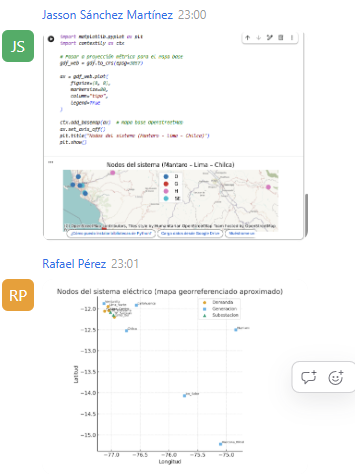

# Herald

https://claude.ai/public/artifacts/b8b9693b-dd22-41c6-b6e1-b2ce3ff40279

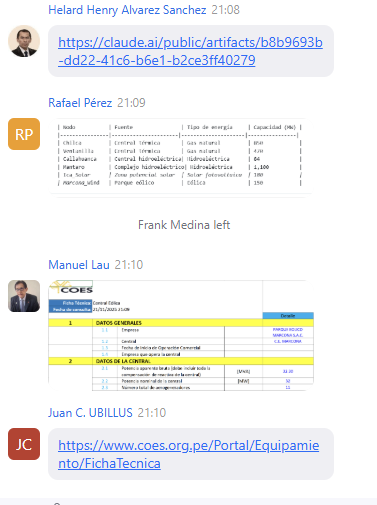

In [5]:
GENERADORES = {
    'Chilca_CCGT': {'bus': 'Chilca', 'p_nom': 800, 'type': 'CCGT',
                   'marginal_cost': 35, 'carrier': 'gas', 'efficiency': 0.55,
                   'co2_emissions': 0.37},  # tCO2/MWh
    'Ventanilla_CCGT': {'bus': 'Ventanilla', 'p_nom': 500, 'type': 'CCGT',
                       'marginal_cost': 38, 'carrier': 'gas', 'efficiency': 0.52,
                       'co2_emissions': 0.40},
    'Callahuanca_Hydro': {'bus': 'Callahuanca', 'p_nom': 80, 'type': 'hydro',
                         'marginal_cost': 5, 'carrier': 'hydro', 'efficiency': 0.90,
                         'co2_emissions': 0},
    'Mantaro_Hydro': {'bus': 'Mantaro', 'p_nom': 900, 'type': 'hydro',
                     'marginal_cost': 3, 'carrier': 'hydro', 'efficiency': 0.92,
                     'co2_emissions': 0},
    'Ica_Solar': {'bus': 'Ica_Solar', 'p_nom': 300, 'type': 'solar',
                 'marginal_cost': 0, 'carrier': 'solar', 'efficiency': 1.0,
                 'co2_emissions': 0, 'p_nom_extendable': True, 'capital_cost': 45000},
    'Marcona_Wind': {'bus': 'Marcona_Wind', 'p_nom': 260, 'type': 'wind',
                    'marginal_cost': 0, 'carrier': 'wind', 'efficiency': 1.0,
                    'co2_emissions': 0, 'p_nom_extendable': True, 'capital_cost': 55000},
}

# Daniel Cachi

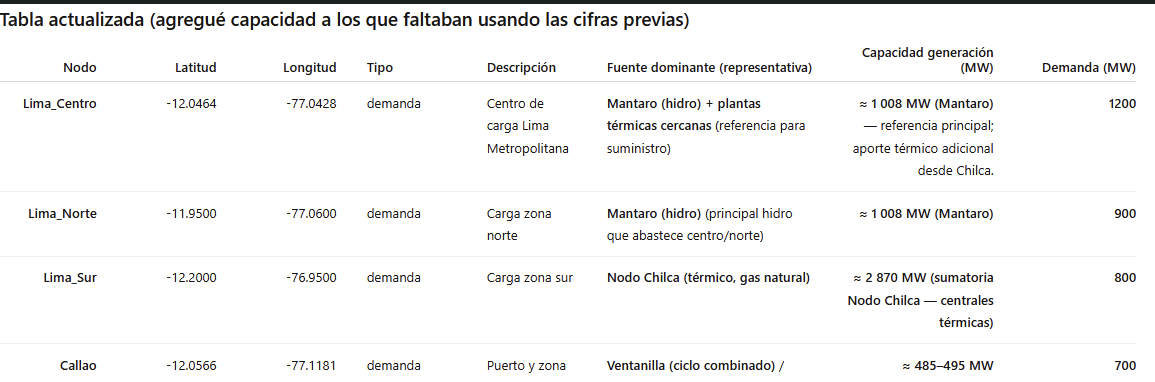

In [6]:
# Demanda pico por nodo (MW) - Datos estimados para Lima Metropolitana
DEMANDA_PICO = {
    'Lima_Centro': 1200,
    'Lima_Norte': 900,
    'Lima_Sur': 800,
    'Callao': 700,
}

# Líneas de transmisión (capacidad en MW, reactancia en p.u.)

Bus: (barra o nodo) es un punto del sistema eléctrico donde es conectan diferentes elementos del sistema, generadores, lineas de transmisión.


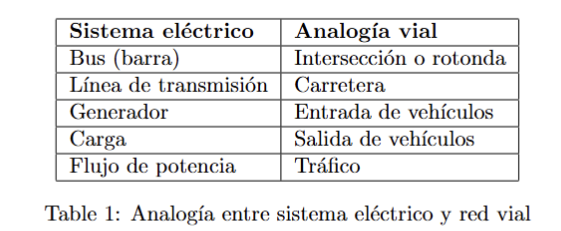

- s_nom: potencia nominal (MVA: Mega voltios-amperio)

                           nota: 1 MVA * pf = MW

                           pf varia de 0 a 1

- x: 0.02 (oposición al flujo de corriente),

- length: distancia física de la linea en km
- bus0: Punto de origen.
- bus1: Punto de destino.

In [7]:
LINEAS = {
    'Mantaro-SE_Chavarria': {'bus0': 'Mantaro', 'bus1': 'SE_Chavarria',
                            's_nom': 1000, 'x': 0.02, 'length': 250},
    'Callahuanca-SE_Chavarria': {'bus0': 'Callahuanca', 'bus1': 'SE_Chavarria',
                                 's_nom': 200, 'x': 0.01, 'length': 50},
    'Chilca-SE_SanJuan': {'bus0': 'Chilca', 'bus1': 'SE_SanJuan',
                         's_nom': 800, 'x': 0.015, 'length': 60},
    'Ventanilla-SE_Chavarria': {'bus0': 'Ventanilla', 'bus1': 'SE_Chavarria',
                                's_nom': 600, 'x': 0.008, 'length': 25},
    'SE_Chavarria-Lima_Centro': {'bus0': 'SE_Chavarria', 'bus1': 'Lima_Centro',
                                 's_nom': 1500, 'x': 0.005, 'length': 10},
    'SE_Chavarria-Lima_Norte': {'bus0': 'SE_Chavarria', 'bus1': 'Lima_Norte',
                                's_nom': 800, 'x': 0.008, 'length': 15},
    'SE_SanJuan-Lima_Sur': {'bus0': 'SE_SanJuan', 'bus1': 'Lima_Sur',
                           's_nom': 700, 'x': 0.007, 'length': 20},
    'SE_SanJuan-Callao': {'bus0': 'SE_SanJuan', 'bus1': 'Callao',
                         's_nom': 500, 'x': 0.01, 'length': 30},
    'Lima_Centro-Callao': {'bus0': 'Lima_Centro', 'bus1': 'Callao',
                          's_nom': 400, 'x': 0.006, 'length': 12},
    'Ica_Solar-SE_SanJuan': {'bus0': 'Ica_Solar', 'bus1': 'SE_SanJuan',
                            's_nom': 500, 'x': 0.03, 'length': 200},
    'Marcona_Wind-Ica_Solar': {'bus0': 'Marcona_Wind', 'bus1': 'Ica_Solar',
                              's_nom': 400, 'x': 0.025, 'length': 150},
}

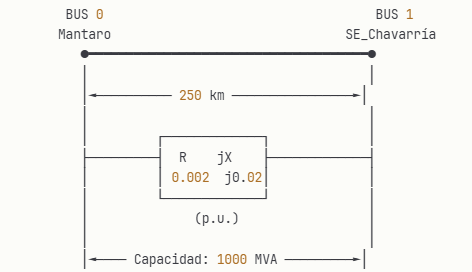

In [8]:
!pip install geopandas simplekml contextily shapely --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [9]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Diccionario de nodos con coordenadas aproximadas
nodos = [
    # nombre,        tipo,   latitud,   longitud
    ("Mantaro",      "H",   -12.08,  -74.63),
    ("Callahuanca",  "H",   -11.90,  -76.62),
    ("Chilca",       "G",   -12.60,  -76.73),
    ("SE Chav.",     "SE",  -12.06,  -77.01),   # aprox. Chavarría / zona centro
    ("SE S.Juan",    "SE",  -12.15,  -76.98),

    ("Lima Centro",  "D",   -12.06,  -77.04),

    ("Lima Norte",   "D",   -11.95,  -77.06),

    ("Lima Sur",     "D",   -12.16,  -76.97),

    ("Callao",       "D",   -12.05,  -77.13),

]

df = pd.DataFrame(nodos, columns=["nombre", "tipo", "lat", "lon"])

# GeoDataFrame (importante: primero lon, luego lat en Point)

gdf = gpd.GeoDataFrame(

    df,

    geometry=[Point(xy) for xy in zip(df["lon"], df["lat"])],

    crs="EPSG:4326"   # WGS84, el que usa Google Earth

)

gdf

,nombre,tipo,lat,lon,geometry
0,Mantaro,H,-12.08,-74.63,POINT (-74.63 -12.08)
1,Callahuanca,H,-11.90,-76.62,POINT (-76.62 -11.9)
2,Chilca,G,-12.60,-76.73,POINT (-76.73 -12.6)
3,SE Chav.,SE,-12.06,-77.01,POINT (-77.01 -12.06)
4,SE S.Juan,SE,-12.15,-76.98,POINT (-76.98 -12.15)
5,Lima Centro,D,-12.06,-77.04,POINT (-77.04 -12.06)
6,Lima Norte,D,-11.95,-77.06,POINT (-77.06 -11.95)
7,Lima Sur,D,-12.16,-76.97,POINT (-76.97 -12.16)
8,Callao,D,-12.05,-77.13,POINT (-77.13 -12.05)


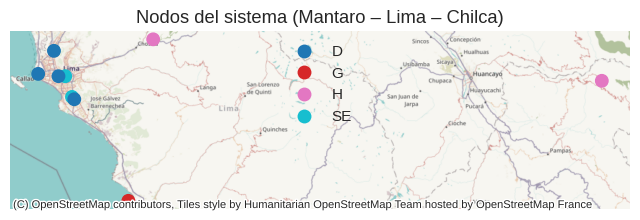

In [10]:
import matplotlib.pyplot as plt
import contextily as ctx

# Pasar a proyección métrica para el mapa base
gdf_web = gdf.to_crs(epsg=3857)
ax = gdf_web.plot(
    figsize=(8, 8),
    markersize=80,
    column="tipo",
    legend=True
)
ctx.add_basemap(ax)  # Mapa base OpenStreetMap
ax.set_axis_off()
plt.title("Nodos del sistema (Mantaro – Lima – Chilca)")

plt.show()

In [11]:
gdf.to_file("nodos_mantaro_lima_chilca.gpkg", layer="nodos", driver="GPKG")

In [12]:
import simplekml

kml = simplekml.Kml()

for _, row in gdf.iterrows():
    pnt = kml.newpoint(
        name=row["nombre"],
        coords=[(row["lon"], row["lat"])]
    )
    # Estilo simple según tipo
    if row["tipo"] == "H":
        pnt.style.iconstyle.color = simplekml.Color.blue
    elif row["tipo"] == "G":
        pnt.style.iconstyle.color = simplekml.Color.red
    elif row["tipo"] == "D":
        pnt.style.iconstyle.color = simplekml.Color.orange
    else:  # SE
        pnt.style.iconstyle.color = simplekml.Color.green

kml.save("nodos_sistema_lima.kml")
print("Archivo KML generado: nodos_sistema_lima.kml")


Archivo KML generado: nodos_sistema_lima.kml


# Perfiles temporales

In [13]:
def generar_perfil_demanda(horas=24*7, pico_mw=2700, tipo='verano'):
    """
    Genera perfil de demanda horaria para Lima
    Basado en patrones típicos del SEIN
    """
    t = np.arange(horas)
    hora_dia = t % 24
    dia_semana = (t // 24) % 7

    # Patrón diario base (normalizado)
    patron_diario = np.zeros(24)
    patron_diario[0:6] = 0.55    # Madrugada
    patron_diario[6:9] = 0.70    # Mañana temprano
    patron_diario[9:12] = 0.85   # Mañana
    patron_diario[12:14] = 0.80  # Almuerzo
    patron_diario[14:18] = 0.85  # Tarde
    patron_diario[18:22] = 1.00  # Punta (18:00-22:00)
    patron_diario[22:24] = 0.70  # Noche

    # Suavizar el patrón
    from scipy.ndimage import gaussian_filter1d
    patron_diario = gaussian_filter1d(patron_diario, sigma=1)

    # Factor por día de semana (lunes=0, domingo=6)
    factor_semana = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 0.85, 0.75])

    # Factor estacional
    factor_estacion = 1.1 if tipo == 'verano' else 0.95

    # Construir perfil completo
    perfil = np.zeros(horas)
    for i in range(horas):
        h = hora_dia[i]
        d = dia_semana[i]
        perfil[i] = patron_diario[h] * factor_semana[d] * factor_estacion

    # Añadir ruido aleatorio (±5%)
    np.random.seed(42)
    ruido = 1 + np.random.uniform(-0.05, 0.05, horas)
    perfil = perfil * ruido * pico_mw

    return perfil

In [14]:
len(generar_perfil_demanda())

168

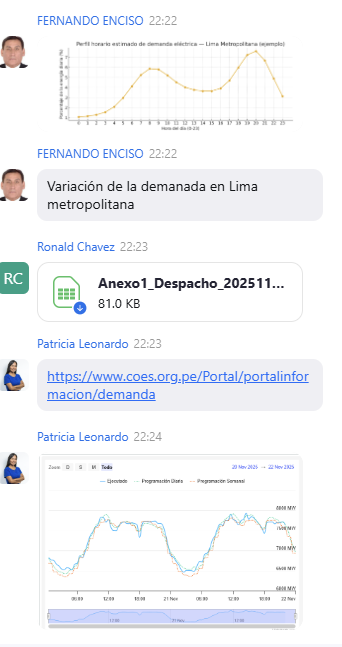

In [15]:
def generar_perfil_solar(horas=24*7, latitud=-14.0):
    """
    Genera perfil de generación solar para Ica/Lima
    Radiación solar típica del desierto costero peruano
    """
    t = np.arange(horas)
    hora_dia = t % 24

    perfil = np.zeros(horas)
    for i in range(horas):
        h = hora_dia[i]
        if 6 <= h <= 18:
            # Modelo simplificado de radiación solar
            angulo = np.pi * (h - 6) / 12
            perfil[i] = np.sin(angulo) ** 1.2
        else:
            perfil[i] = 0

    # Añadir variabilidad por nubes (costa peruana tiene pocas nubes en verano)
    np.random.seed(123)
    nubes = 1 - np.random.uniform(0, 0.15, horas)
    perfil = perfil * nubes

    return np.clip(perfil, 0, 1)

In [16]:
def generar_perfil_eolico(horas=24*7):
    """
    Genera perfil de generación eólica para Marcona
    Vientos fuertes y constantes del Pacífico sur
    """
    t = np.arange(horas)
    hora_dia = t % 24

    # Patrón base: vientos más fuertes en tarde/noche
    patron_base = np.zeros(24)
    patron_base[0:6] = 0.65
    patron_base[6:12] = 0.45
    patron_base[12:18] = 0.55
    patron_base[18:24] = 0.75

    perfil = np.zeros(horas)
    for i in range(horas):
        h = hora_dia[i]
        perfil[i] = patron_base[h]

    # Añadir variabilidad realista
    np.random.seed(456)
    variabilidad = np.random.uniform(0.7, 1.3, horas)
    perfil = perfil * variabilidad

    return np.clip(perfil, 0, 1)

In [17]:
def generar_perfil_hidro(horas=24*7, mes='febrero'):
    """
    Genera perfil de disponibilidad hidroeléctrica
    Considera estacionalidad del Mantaro y ríos de Lima
    """
    # Factores mensuales (mayor disponibilidad en época húmeda: dic-abril)
    factores_mes = {
        'enero': 0.95, 'febrero': 1.0, 'marzo': 0.98,
        'abril': 0.90, 'mayo': 0.80, 'junio': 0.70,
        'julio': 0.65, 'agosto': 0.60, 'septiembre': 0.65,
        'octubre': 0.70, 'noviembre': 0.80, 'diciembre': 0.90
    }

    factor = factores_mes.get(mes, 0.75)

    # Perfil relativamente constante con pequeñas variaciones, ruido
    np.random.seed(789)
    perfil = factor * (1 + np.random.uniform(-0.05, 0.05, horas))

    return np.clip(perfil, 0, 1)

# basado en esos 3 ejemplos de generadores, crear una función para un generador geotérmico

def generar_perfil_geotermico() ...

https://claude.ai/public/artifacts/61412759-4fec-48f5-bf4b-4104be65a9cb

Helard

Applicación


In [18]:
# Manuel Lau
def generar_perfil_geotermico(horas=24*7, mes='febrero'):
    """
    Genera perfil de disponibilidad geotérmica.
    Considera que la geotermia es generación base y muy estable,
    con ligerísimas variaciones anuales.
    """
    # Factores mensuales (muy estables: leves ajustes por mantenimiento)
    factores_mes = {
        'enero': 0.97, 'febrero': 0.98, 'marzo': 0.99,
        'abril': 1.00, 'mayo': 1.00, 'junio': 0.99,
        'julio': 0.98, 'agosto': 0.97, 'septiembre': 0.98,
        'octubre': 0.99, 'noviembre': 1.00, 'december': 0.99
    }
    # Si el mes no está, asigna valor base
    factor = factores_mes.get(mes.lower(), 0.98)
    # Perfil extremadamente constante con muy poco ruido
    np.random.seed(321)
    perfil = factor * (1 + np.random.uniform(-0.01, 0.01, horas))
    return np.clip(perfil, 0, 1)

# Imprimir resultados de perfiles


In [19]:
HORAS_SIMULACION = 24 * 7
snapshots = pd.date_range('2025-10-01', periods=HORAS_SIMULACION, freq='h')

perfil_demanda = generar_perfil_demanda(HORAS_SIMULACION)
perfil_solar = generar_perfil_solar(HORAS_SIMULACION)
perfil_eolico = generar_perfil_eolico(HORAS_SIMULACION)
perfil_hidro = generar_perfil_hidro(HORAS_SIMULACION, mes='octubre')

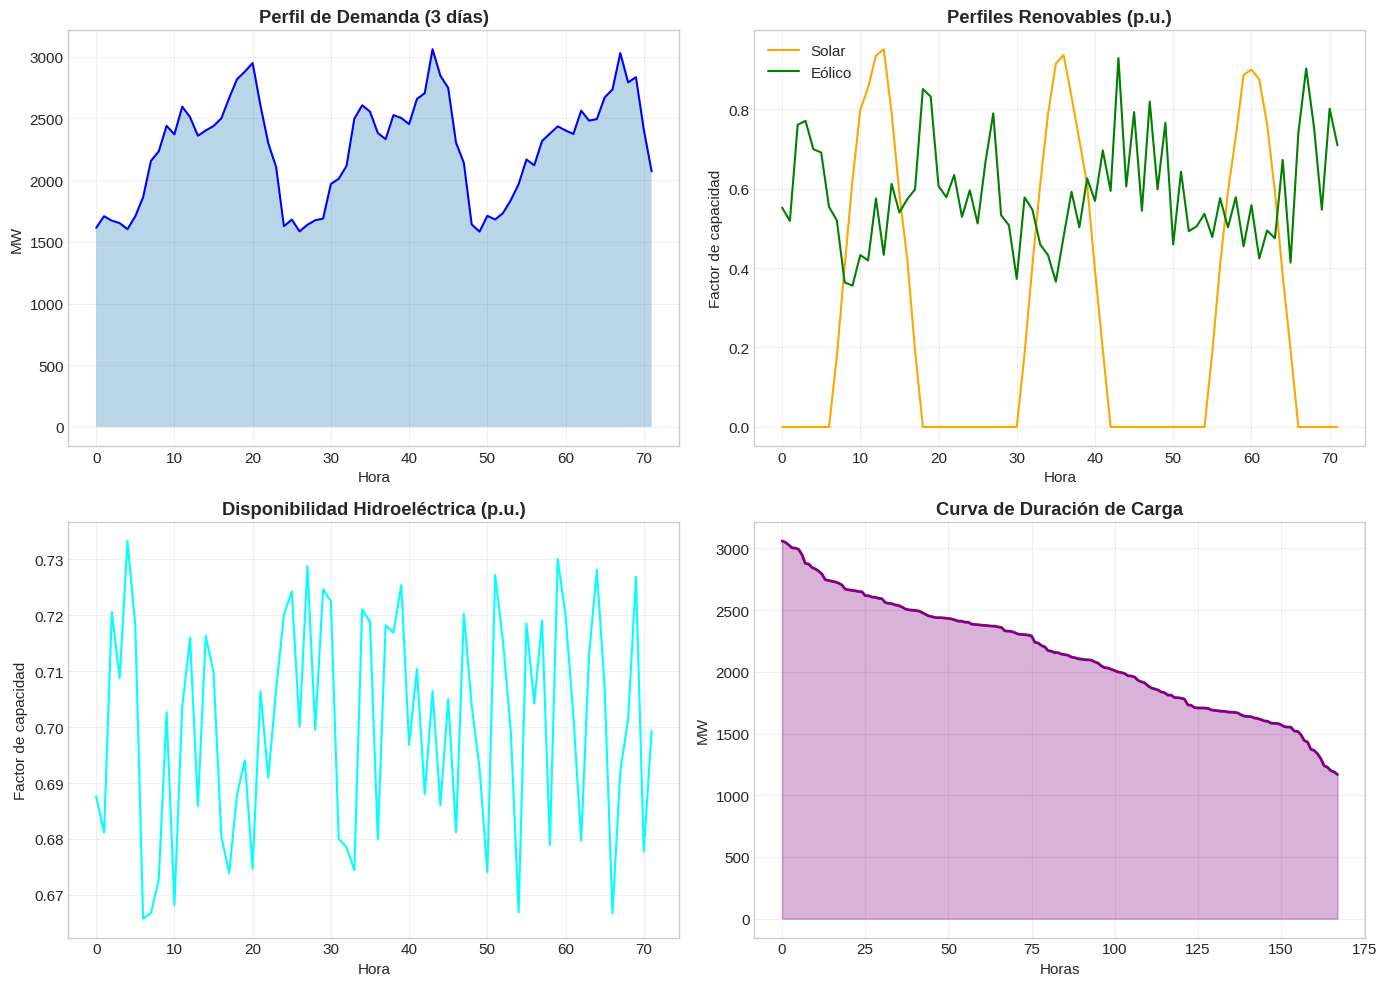

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(perfil_demanda[:72], 'b-', linewidth=1.5)
axes[0,0].set_title('Perfil de Demanda (3 días)', fontweight='bold')
axes[0,0].set_xlabel('Hora')
axes[0,0].set_ylabel('MW')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].fill_between(range(72), perfil_demanda[:72], alpha=0.3)

axes[0,1].plot(perfil_solar[:72], 'orange', linewidth=1.5, label='Solar')
axes[0,1].plot(perfil_eolico[:72], 'green', linewidth=1.5, label='Eólico')

axes[0,1].set_title('Perfiles Renovables (p.u.)', fontweight='bold')
axes[0,1].set_xlabel('Hora')
axes[0,1].set_ylabel('Factor de capacidad')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(perfil_hidro[:72], 'cyan', linewidth=1.5)
axes[1,0].set_title('Disponibilidad Hidroeléctrica (p.u.)', fontweight='bold')
axes[1,0].set_xlabel('Hora')
axes[1,0].set_ylabel('Factor de capacidad')
axes[1,0].grid(True, alpha=0.3)

# Curva de duración de carga
demanda_ordenada = np.sort(perfil_demanda)[::-1]
axes[1,1].plot(demanda_ordenada, 'purple', linewidth=2)
axes[1,1].set_title('Curva de Duración de Carga', fontweight='bold')
axes[1,1].set_xlabel('Horas')
axes[1,1].set_ylabel('MW')
axes[1,1].fill_between(range(len(demanda_ordenada)), demanda_ordenada, alpha=0.3, color='purple')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()

Agregando geotermica (no parte del modelo)

In [21]:
perfil_geotermico = generar_perfil_geotermico(HORAS_SIMULACION, mes='octubre')

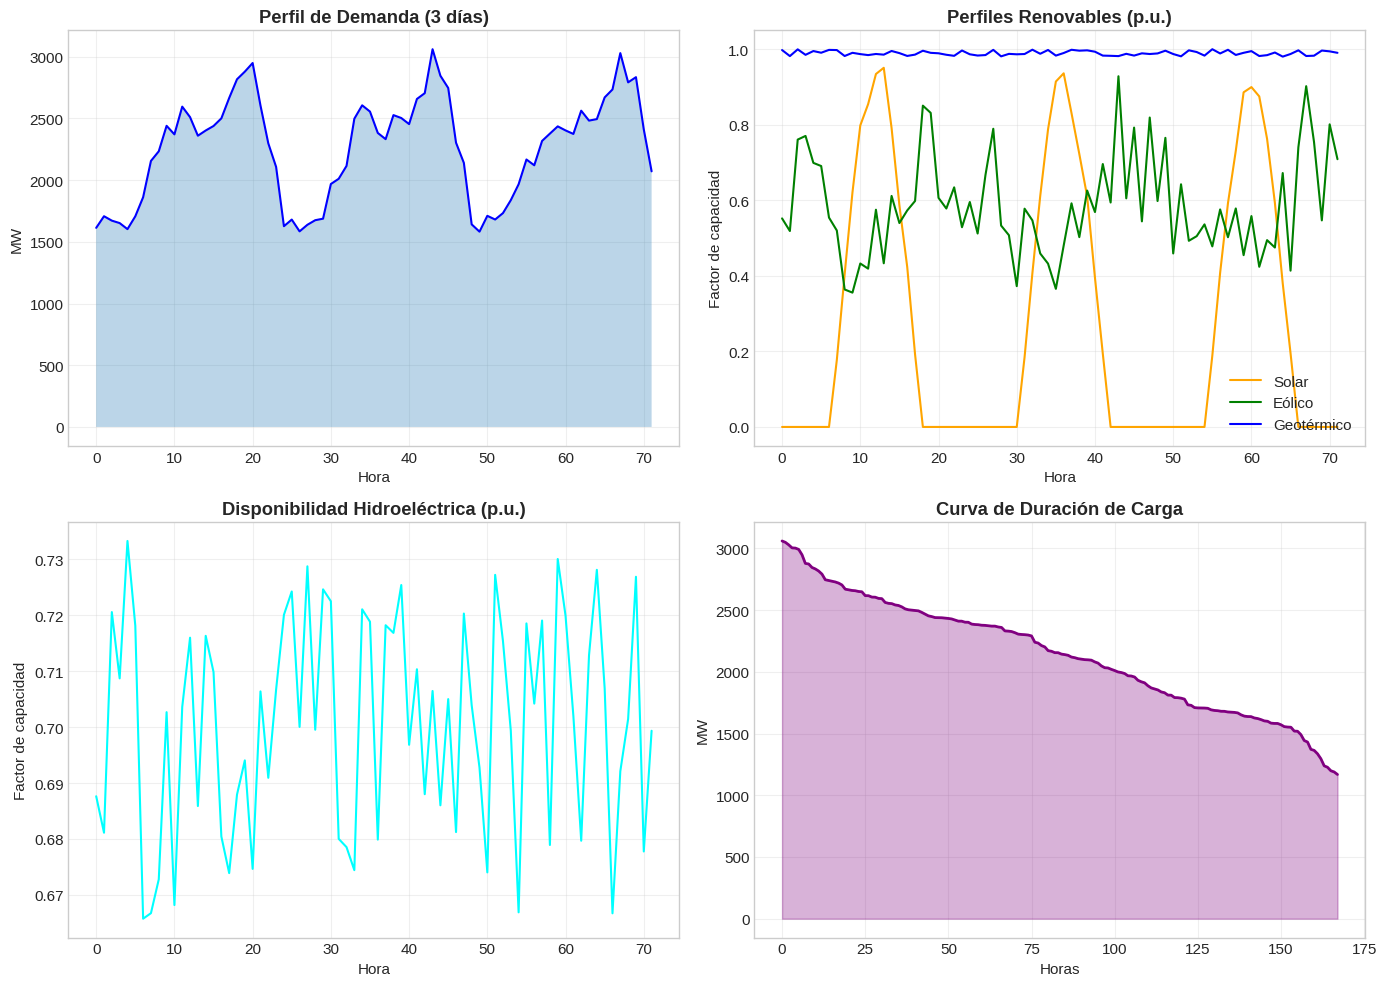

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(perfil_demanda[:72], 'b-', linewidth=1.5)
axes[0,0].set_title('Perfil de Demanda (3 días)', fontweight='bold')
axes[0,0].set_xlabel('Hora')
axes[0,0].set_ylabel('MW')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].fill_between(range(72), perfil_demanda[:72], alpha=0.3)

axes[0,1].plot(perfil_solar[:72], 'orange', linewidth=1.5, label='Solar')
axes[0,1].plot(perfil_eolico[:72], 'green', linewidth=1.5, label='Eólico')
axes[0,1].plot(perfil_geotermico[:72], 'blue', linewidth=1.5, label='Geotérmico')

axes[0,1].set_title('Perfiles Renovables (p.u.)', fontweight='bold')
axes[0,1].set_xlabel('Hora')
axes[0,1].set_ylabel('Factor de capacidad')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(perfil_hidro[:72], 'cyan', linewidth=1.5)
axes[1,0].set_title('Disponibilidad Hidroeléctrica (p.u.)', fontweight='bold')
axes[1,0].set_xlabel('Hora')
axes[1,0].set_ylabel('Factor de capacidad')
axes[1,0].grid(True, alpha=0.3)

# Curva de duración de carga
demanda_ordenada = np.sort(perfil_demanda)[::-1]
axes[1,1].plot(demanda_ordenada, 'purple', linewidth=2)
axes[1,1].set_title('Curva de Duración de Carga', fontweight='bold')
axes[1,1].set_xlabel('Horas')
axes[1,1].set_ylabel('MW')
axes[1,1].fill_between(range(len(demanda_ordenada)), demanda_ordenada, alpha=0.3, color='purple')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()

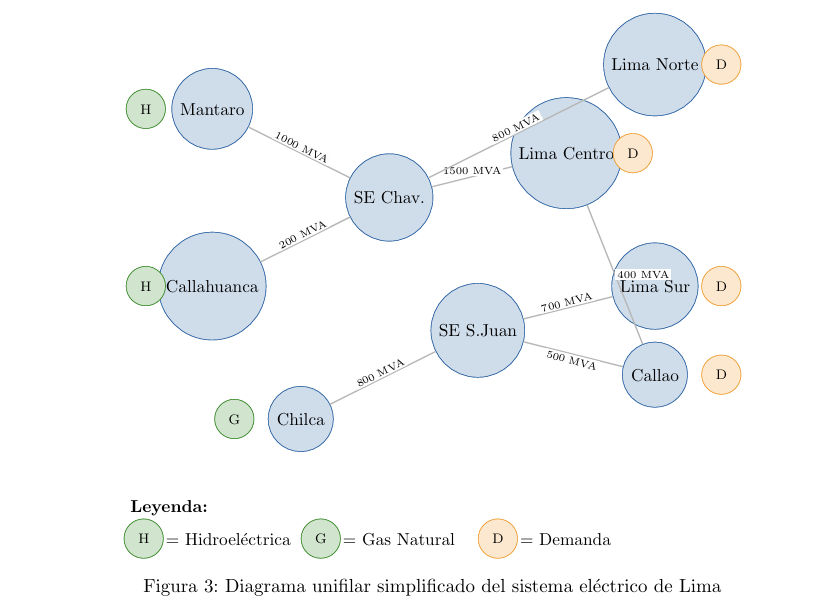

In [23]:

# Lista de líneas: (origen, destino)

lineas = [

    ("Mantaro", "SE Chav."),

    ("Callahuanca", "SE Chav."),

    ("Chilca", "SE S.Juan"),

    ("SE S.Juan", "Lima Sur"),

    ("SE S.Juan", "Callao"),

    ("SE Chav.", "Lima Centro"),

    ("Lima Centro", "Lima Norte"),

    ("Lima Centro", "Lima Sur"),

]

for origen, destino in lineas:

    o = gdf[gdf["nombre"] == origen].iloc[0]

    d = gdf[gdf["nombre"] == destino].iloc[0]

    lin = kml.newlinestring(

        name=f"{origen} - {destino}",

        coords=[(o["lon"], o["lat"]), (d["lon"], d["lat"])]

    )

    lin.style.linestyle.width = 2

    lin.style.linestyle.color = simplekml.Color.gray

kml.save("nodos_y_lineas_lima.kml")

print("Archivo KML generado: nodos_y_lineas_lima.kml")

Archivo KML generado: nodos_y_lineas_lima.kml


In [24]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

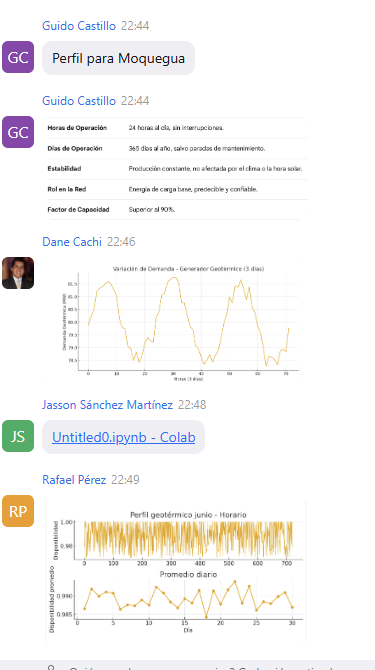

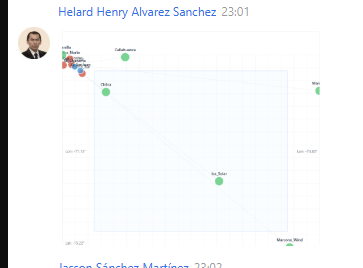

# Generación del modelo en PyPSA